In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_iris

In [3]:
data = load_iris()

In [4]:
x = data.data

In [5]:
y = data.target

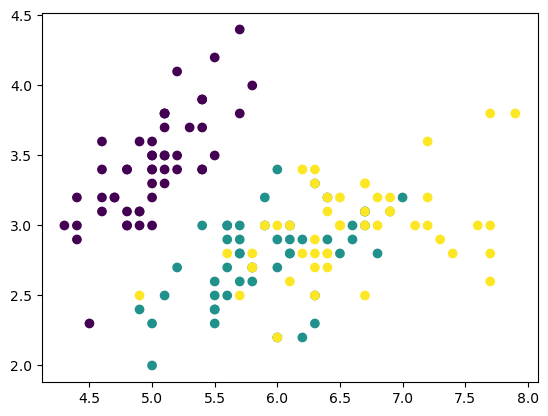

In [6]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

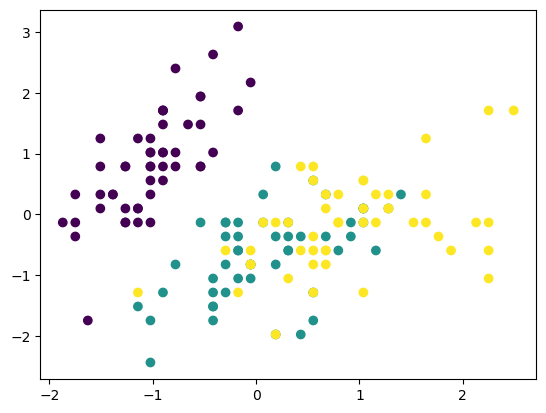

In [8]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c = y)
plt.show()

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(x_scaled)

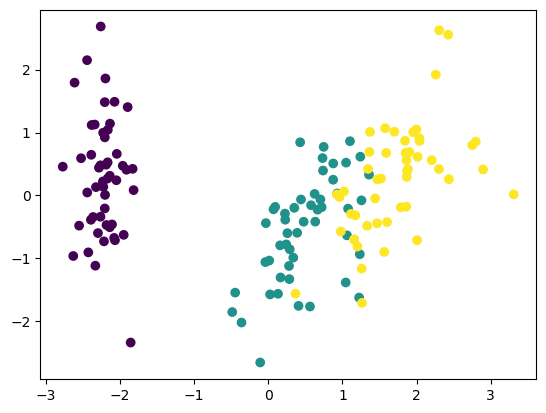

In [10]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c = y)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test,y_train,y_test = train_test_split(pca_scaled,y,test_size=0.3,random_state=1)

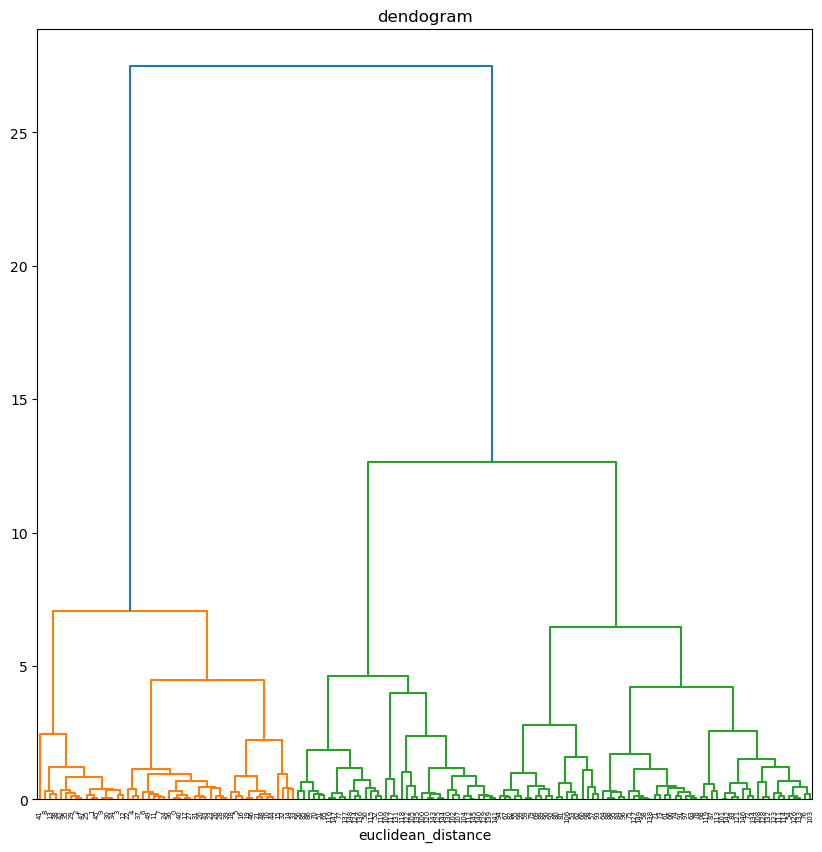

In [12]:
# dindograms for agglomoerative clustering
import  scipy.cluster.hierarchy as sc

plt.figure(figsize=(10,10))
plt.title('dendogram')
sc.dendrogram(sc.linkage(pca_scaled, method='ward'))
plt.xlabel('euclidean_distance')
plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3,metric = 'euclidean',linkage = 'ward')
model

AgglomerativeClustering(n_clusters=3)

In [14]:
# aglomorotive clusteriing
model.fit(x_train)

AgglomerativeClustering(n_clusters=3)

In [15]:
model.labels_

array([2, 0, 0, 0, 1, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1, 0, 1, 1, 0, 0, 2, 0,
       1, 2, 1, 1, 2, 1, 0, 1, 1, 2, 1, 2, 1, 0, 0, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 0, 1, 0, 1, 2, 0, 1, 0, 0, 2, 1,
       2, 0, 0, 1, 0, 1, 0, 2, 1, 0, 2, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 2, 1, 1, 2, 1, 2, 0], dtype=int64)

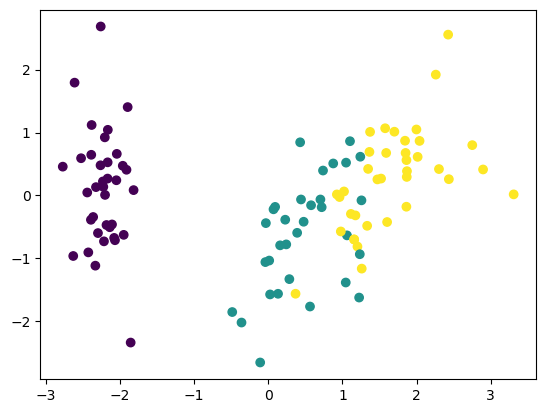

In [16]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
silhouette_score(x_train,model.labels_)

0.5141220618029466